<a href="https://colab.research.google.com/github/IsaacBFine/diabetes-predictors/blob/main/Notebooks/feature_engineering_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering Notebook

Feature engineering transforms raw data into potentially meaningful inputs that improve a machine learning model's ability to identify patterns.

While designing a neural network would vastly improve the accuracy of our predictions, it lacks interpretability.

With feature engineering we can get a better idea of how some variables affect other variables, giving us a wider picture of the the collinearity of our variables.

First we're going to import the dataset and necessary dependencies. Then we're going to move into our data exploration, and then end with finalizing our feature engineered model.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

import pandas as pd

url = "https://raw.githubusercontent.com/IsaacBFine/diabetes-predictors/refs/heads/main/Data/clean/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

df = pd.read_csv(url)

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
random.seed(67)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# assumes df is already loaded
target        = "Diabetes_binary"
y             = df[target].values
X_raw         = df.drop(columns=[target])
feature_names = list(X_raw.columns)


# Exploratory Work:

### 1. Correlation Heatmap
We started the exploration by creating this correlation heatmap to see the interrelatedness of our variables.

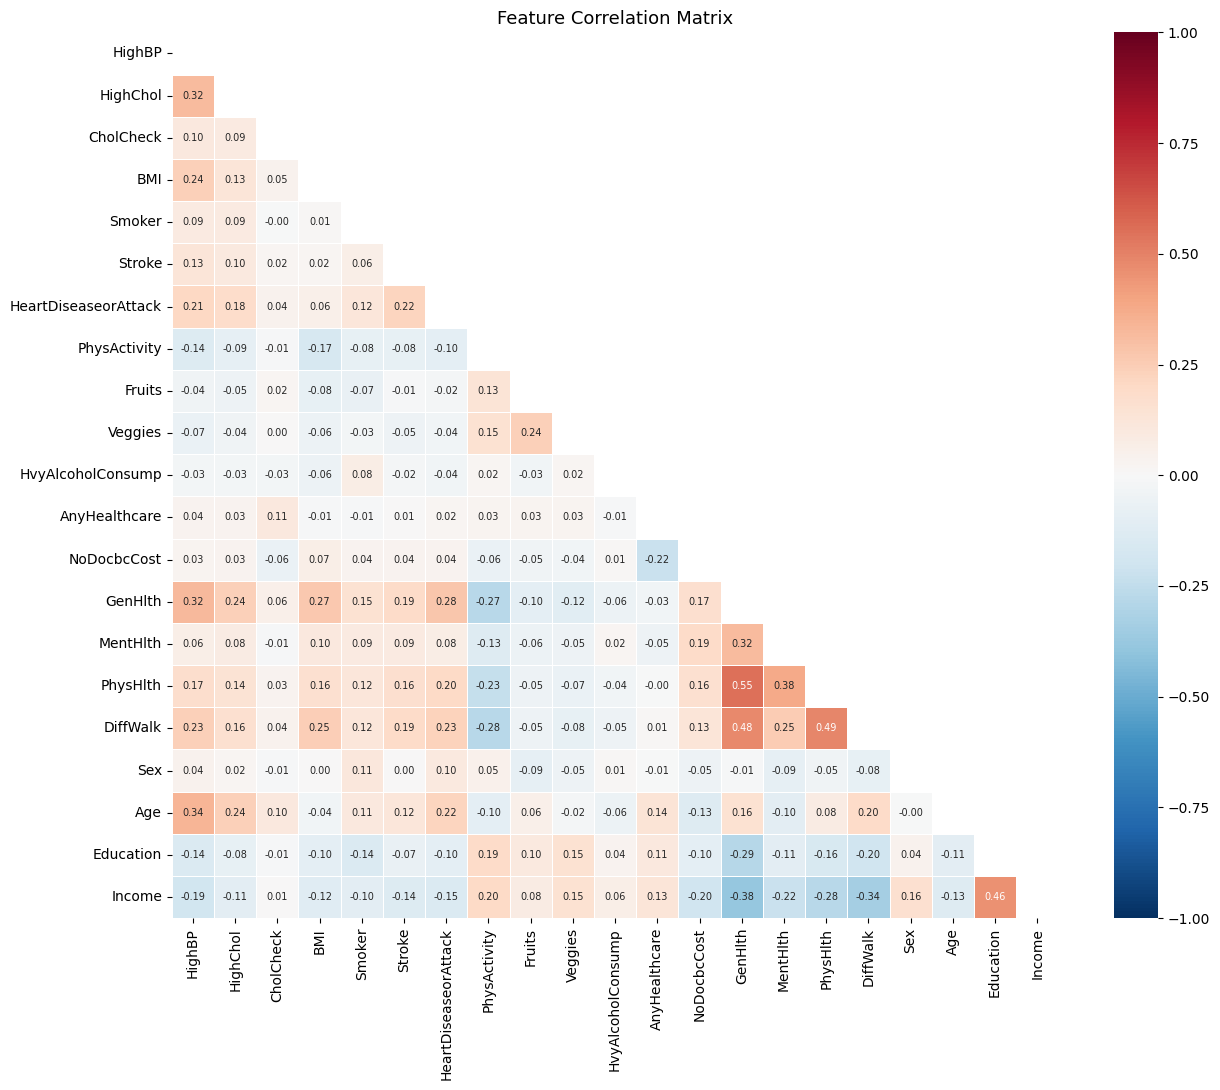

Pairs with |r| > 0.3:
  HighBP                     x  HighChol                    r = +0.317
  HighBP                     x  GenHlth                     r = +0.321
  HighBP                     x  Age                         r = +0.338
  GenHlth                    x  MentHlth                    r = +0.315
  GenHlth                    x  PhysHlth                    r = +0.553
  GenHlth                    x  DiffWalk                    r = +0.477
  GenHlth                    x  Income                      r = -0.383
  MentHlth                   x  PhysHlth                    r = +0.380
  PhysHlth                   x  DiffWalk                    r = +0.488
  DiffWalk                   x  Income                      r = -0.343
  Education                  x  Income                      r = +0.461


In [5]:
# CORRELATION HEATMAP
corr = X_raw.corr()
plt.figure(figsize=(13, 11))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.4, annot_kws={"size": 7})
plt.title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

print("Pairs with |r| > 0.3:")
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.3:
            print(f"  {corr.columns[i]:25s}  x  {corr.columns[j]:25s}   r = {r:+.3f}")


### 2. VIF Baseline
Then we wanted to see how significantly multicollinearity was affecting our data. So we plotted a Variance Infalction Factor (VIF) baseline.

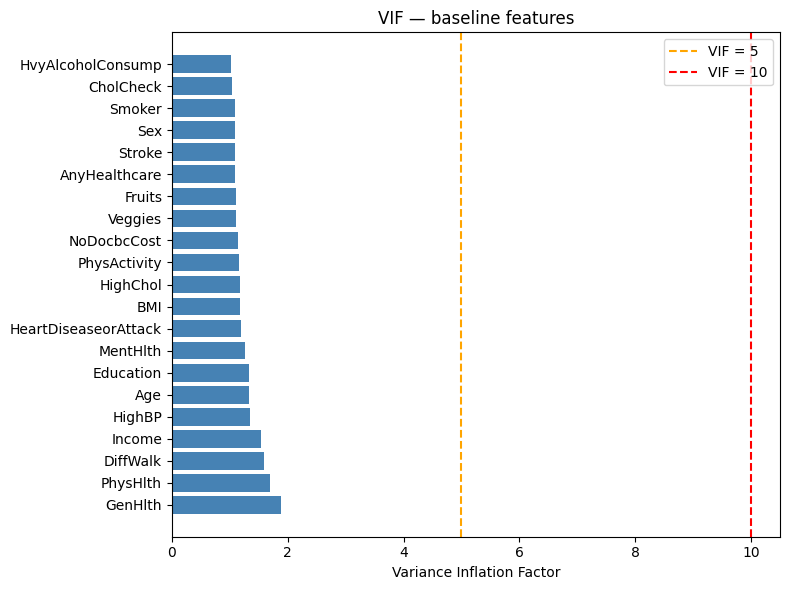

             Feature      VIF
             GenHlth 1.890908
            PhysHlth 1.700399
            DiffWalk 1.591225
              Income 1.544598
              HighBP 1.357474
                 Age 1.337148
           Education 1.331728
            MentHlth 1.267156
HeartDiseaseorAttack 1.193935
                 BMI 1.180737
            HighChol 1.179017
        PhysActivity 1.167430
         NoDocbcCost 1.143393
             Veggies 1.103377
              Fruits 1.101333
       AnyHealthcare 1.095602
              Stroke 1.094027
                 Sex 1.088941
              Smoker 1.082180
           CholCheck 1.032894
   HvyAlcoholConsump 1.022839


In [6]:
# VIF BASELINE
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

vif_base = pd.DataFrame({
    "Feature": feature_names,
    "VIF":     [variance_inflation_factor(X_scaled, i) for i in range(len(feature_names))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.barh(vif_base["Feature"], vif_base["VIF"],
         color=["red" if v > 10 else "orange" if v > 5 else "steelblue" for v in vif_base["VIF"]])
plt.axvline(5,  color="orange", linestyle="--", label="VIF = 5")
plt.axvline(10, color="red",    linestyle="--", label="VIF = 10")
plt.xlabel("Variance Inflation Factor")
plt.title("VIF — baseline features")
plt.legend()
plt.tight_layout()
plt.show()
print(vif_base.to_string(index=False))

# Feature Engineering Work:

Then we began the feature engineering work. We started by creating pairs and then adapted based on the results.

In [7]:
# INTERACTION TERMS
# binary x binary     -> logical AND (patient has BOTH conditions)
# continuous x binary -> continuous value switched on only when binary = 1
# continuous x continuous -> standard interaction
interaction_pairs = [
    ("HighBP",      "HighChol"),
    ("HighBP",      "HeartDiseaseorAttack"),
    ("HighChol",    "HeartDiseaseorAttack"),
    ("HighBP",      "Stroke"),
    ("BMI",         "PhysActivity"),
    ("BMI",         "Age"),
    ("Smoker",      "HvyAlcoholConsump"),
    ("Fruits",      "Veggies"),
    ("GenHlth",     "PhysHlth"),
    ("GenHlth",     "MentHlth"),
    ("PhysHlth",    "DiffWalk"),
    ("GenHlth",     "DiffWalk"),
    ("Income",      "Education"),
    ("Income",      "AnyHealthcare"),
    ("NoDocbcCost", "AnyHealthcare"),
    ("Age",         "HeartDiseaseorAttack"),
    ("Age",         "Stroke"),
    ("Age",         "DiffWalk"),
]

X_eng = X_raw.copy()
for a, b in interaction_pairs:
    X_eng[f"{a} x {b}"] = X_raw[a] * X_raw[b]

interaction_names = [f"{a} x {b}" for a, b in interaction_pairs]
eng_feature_names = list(X_eng.columns)
print(f"\nOriginal features: {X_raw.shape[1]}  ->  After engineering: {X_eng.shape[1]}")


Original features: 21  ->  After engineering: 39


We chose LASSO as a tool to help us answer our guiding question "Which variables matter?"

We compared a non-engineered logistic LASSO model to the engineered lasso model.


[Baseline] Best C = 0.02154 | Non-zero: 19 / 21


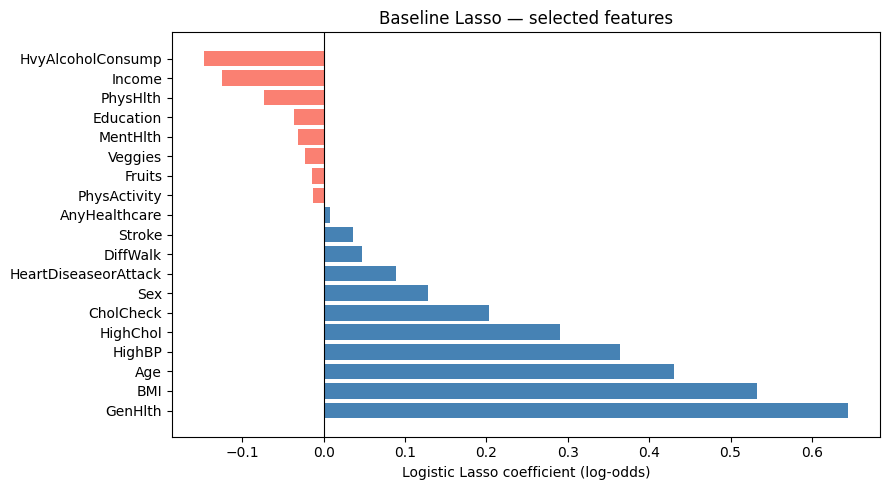


[Engineered] Best C = 0.04375 | Non-zero: 32 / 39
GenHlth                            0.768010
BMI x Age                          0.566516
DiffWalk                           0.530124
HeartDiseaseorAttack               0.438113
HighBP                             0.370977
GenHlth x PhysHlth                -0.369796
GenHlth x DiffWalk                -0.369043
HighChol                           0.302730
PhysHlth                           0.219645
Age x DiffWalk                    -0.205548
CholCheck                          0.204781
Age x HeartDiseaseorAttack        -0.197440
BMI                                0.176822
HvyAlcoholConsump                 -0.160901
Stroke                             0.142492
Sex                                0.128573
HighBP x HeartDiseaseorAttack     -0.096521
HighChol x HeartDiseaseorAttack   -0.096472
Income x Education                -0.092983
Age x Stroke                      -0.090750
PhysActivity                      -0.073749
BMI x PhysActivity       

In [8]:
# LOGISTIC LASSO BASELINE
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Cs  = np.logspace(-3, 1, 40)

lasso_base = LogisticRegressionCV(
    Cs=Cs, penalty="l1", solver="liblinear",
    cv=cv, max_iter=1000, random_state=42, scoring="roc_auc"
)
lasso_base.fit(X_scaled, y)
coef_base = pd.Series(lasso_base.coef_[0], index=feature_names)

print(f"\n[Baseline] Best C = {lasso_base.C_[0]:.5f} | Non-zero: {(coef_base != 0).sum()} / {len(feature_names)}")
nonzero_base = coef_base[coef_base != 0].sort_values(ascending=False)
plt.figure(figsize=(9, 5))
plt.barh(nonzero_base.index, nonzero_base.values,
         color=["steelblue" if v > 0 else "salmon" for v in nonzero_base])
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Logistic Lasso coefficient (log-odds)")
plt.title("Baseline Lasso — selected features")
plt.tight_layout()
plt.show()

# LOGISTIC LASSO ENGINEERED
X_eng_scaled = StandardScaler().fit_transform(X_eng)

lasso_eng = LogisticRegressionCV(
    Cs=Cs, penalty="l1", solver="liblinear",
    cv=cv, max_iter=1000, random_state=42, scoring="roc_auc"
)
lasso_eng.fit(X_eng_scaled, y)
coef_eng = pd.Series(lasso_eng.coef_[0], index=eng_feature_names)

print(f"\n[Engineered] Best C = {lasso_eng.C_[0]:.5f} | Non-zero: {(coef_eng != 0).sum()} / {len(eng_feature_names)}")
print(coef_eng[coef_eng != 0].sort_values(key=abs, ascending=False).to_string())


We then compared the non-engineered LASSO against the engineered LASSO to understand if there was any improvement in our prediction accuracy, and specifically which interactions were chosen by the model.


=== Sign flips ===
          baseline  engineered
Fruits   -0.014171    0.011403
PhysHlth -0.073406    0.219645

=== Dropped after engineering ===
['Age', 'Education']

=== Newly selected after engineering ===
        baseline  engineered
Smoker       0.0   -0.004847


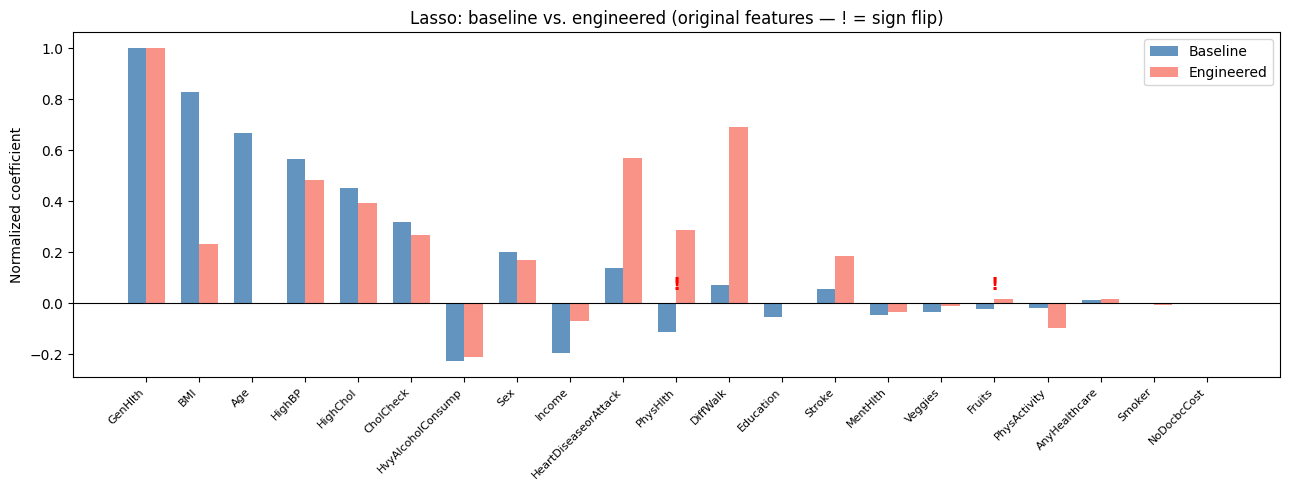


=== Interaction terms selected by Lasso ===
BMI x Age                          0.566516
GenHlth x PhysHlth                -0.369796
GenHlth x DiffWalk                -0.369043
Age x DiffWalk                    -0.205548
Age x HeartDiseaseorAttack        -0.197440
HighBP x HeartDiseaseorAttack     -0.096521
HighChol x HeartDiseaseorAttack   -0.096472
Income x Education                -0.092983
Age x Stroke                      -0.090750
BMI x PhysActivity                 0.065612
PhysHlth x DiffWalk                0.045122
Fruits x Veggies                  -0.037764
Smoker x HvyAlcoholConsump         0.012659
HighBP x Stroke                   -0.011711

--- Component status ---
  BMI x Age: +0.5665
    BMI: +0.1768
    Age: +0.0000  (zeroed)
  GenHlth x PhysHlth: -0.3698
    GenHlth: +0.7680
    PhysHlth: +0.2196
  GenHlth x DiffWalk: -0.3690
    GenHlth: +0.7680
    DiffWalk: +0.5301
  Age x DiffWalk: -0.2055
    Age: +0.0000  (zeroed)
    DiffWalk: +0.5301
  Age x HeartDiseaseorAttac

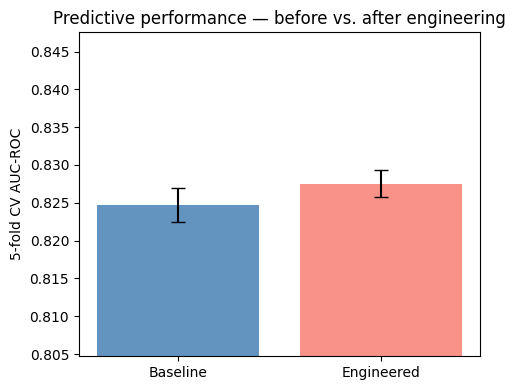

In [ ]:
# BEFORE VS AFTER COMPARISON
compare = pd.DataFrame({
    "baseline":   coef_base,
    "engineered": coef_eng[feature_names],
})
compare["changed_sign"] = (
    (compare["baseline"] != 0) & (compare["engineered"] != 0) &
    (np.sign(compare["baseline"]) != np.sign(compare["engineered"]))
)
compare["dropped"] = (compare["baseline"] != 0) & (compare["engineered"] == 0)
compare["gained"]  = (compare["baseline"] == 0) & (compare["engineered"] != 0)

print("\n=== Sign flips ===")
flips = compare[compare["changed_sign"]][["baseline", "engineered"]]
print(flips.to_string() if len(flips) else "  None")
print("\n=== Dropped after engineering ===")
print(compare[compare["dropped"]].index.tolist() or "  None")
print("\n=== Newly selected after engineering ===")
gained = compare[compare["gained"]][["baseline", "engineered"]]
print(gained.to_string() if len(gained) else "  None")

norm_b = compare["baseline"]   / (compare["baseline"].abs().max()   + 1e-10)
norm_e = compare["engineered"] / (compare["engineered"].abs().max() + 1e-10)
order  = compare["baseline"].abs().sort_values(ascending=False).index

x, w = np.arange(len(order)), 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, norm_b[order], w, label="Baseline",   color="steelblue", alpha=0.85)
ax.bar(x + w/2, norm_e[order], w, label="Engineered", color="salmon",    alpha=0.85)
for i, feat in enumerate(order):
    if compare.loc[feat, "changed_sign"]:
        ax.annotate("!", xy=(i, 0.05), ha="center", color="red", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha="right", fontsize=8)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Normalized coefficient")
ax.set_title("Lasso: baseline vs. engineered (original features — ! = sign flip)")
ax.legend()
plt.tight_layout()
plt.show()

# WHICH INTERACTIONS WERE SELECTED
sel_int = coef_eng[interaction_names]
sel_int = sel_int[sel_int != 0].sort_values(key=abs, ascending=False)

print("\n=== Interaction terms selected by Lasso ===")
if len(sel_int):
    print(sel_int.to_string())
    print("\n--- Component status ---")
    for name in sel_int.index:
        a, b = name.split(" x ", 1)
        ca, cb = coef_eng.get(a, 0), coef_eng.get(b, 0)
        print(f"  {name}: {sel_int[name]:+.4f}")
        print(f"    {a}: {ca:+.4f}{'  (zeroed)' if ca == 0 else ''}")
        print(f"    {b}: {cb:+.4f}{'  (zeroed)' if cb == 0 else ''}")
else:
    print("  None — Lasso preferred original features over interactions.")

# AUC COMPARISON
def cv_auc(model, X, y, cv):
    aucs = []
    for train_idx, test_idx in cv.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        prob = model.predict_proba(X[test_idx])[:, 1]
        aucs.append(roc_auc_score(y[test_idx], prob))
    return np.mean(aucs), np.std(aucs)

results = {
    "Baseline":   cv_auc(LogisticRegression(C=lasso_base.C_[0], penalty="l1", solver="liblinear", max_iter=1000), X_scaled,     y, cv),
    "Engineered": cv_auc(LogisticRegression(C=lasso_eng.C_[0],  penalty="l1", solver="liblinear", max_iter=1000), X_eng_scaled, y, cv),
}

print("\n=== 5-fold CV AUC-ROC ===")
for name, (mean, std) in results.items():
    print(f"  {name:<12}  {mean:.4f} +/- {std:.4f}")

means = [v[0] for v in results.values()]
stds  = [v[1] for v in results.values()]
plt.figure(figsize=(5, 4))
plt.bar(results.keys(), means, yerr=stds, capsize=5,
        color=["steelblue", "salmon"], alpha=0.85)
plt.ylabel("5-fold CV AUC-ROC")
plt.title("Predictive performance — before vs. after engineering")
plt.ylim(min(means) - 0.02, max(means) + 0.02)
plt.tight_layout()
plt.show()

Then we wanted to visualize what features of the engineered LASSO were important.

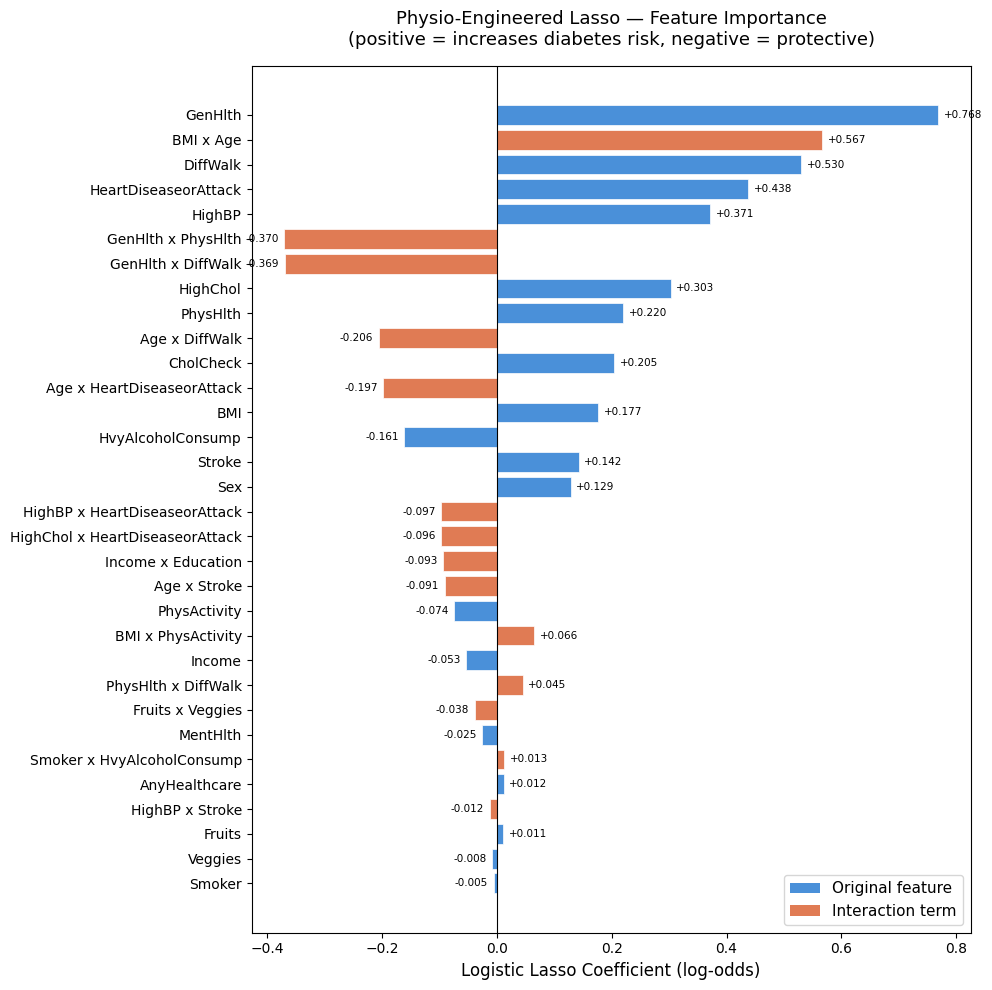

In [9]:
# pull non-zero coefficients and label type
nonzero = coef_eng[coef_eng != 0].copy()
nonzero = nonzero.reindex(nonzero.abs().sort_values(ascending=True).index)

is_interaction = nonzero.index.isin(interaction_names)
colors = ["#e07b54" if inter else "#4a90d9" for inter in is_interaction]

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(nonzero.index, nonzero.values, color=colors, edgecolor="white", linewidth=0.5)

ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Logistic Lasso Coefficient (log-odds)", fontsize=12)
ax.set_title("Physio-Engineered Lasso — Feature Importance\n(positive = increases diabetes risk, negative = protective)",
             fontsize=13, pad=15)

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4a90d9", label="Original feature"),
    Patch(facecolor="#e07b54", label="Interaction term"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=11)

# add coefficient value labels on each bar
for bar, val in zip(bars, nonzero.values):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ha = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=7.5)

plt.tight_layout()
plt.show()


### Socioeconomic Feature Engineering
Then we decided to do another feature engineering, but only on socioeconomic predictors.

Diabetes is influenced by both physiological risk factors as well as broader social determinants of health. By engineering and evaluating these groups separately, we can better understand the relative contribution of each domain to diabetes prediction.

Original features:    21
SES interactions:     18
Total features:       39

[SES Engineered] Best C = 0.01343 | Non-zero: 27 / 39

All selected features:
BMI                         0.520906
Age                         0.420689
Income                     -0.370687
Income x GenHlth            0.299258
HighChol                    0.289426
HighBP                      0.232978
GenHlth                     0.229766
CholCheck                   0.199523
Education x GenHlth         0.152720
HvyAlcoholConsump          -0.145888
Education                  -0.138684
Sex                         0.126961
Education x HighBP          0.118508
HeartDiseaseorAttack        0.088618
DiffWalk                    0.049783
Income x PhysHlth          -0.039332
Stroke                      0.035014
MentHlth                   -0.023313
AnyHealthcare x PhysHlth   -0.021150
Veggies                    -0.020265
Education x PhysActivity   -0.017017
AnyHealthcare x GenHlth     0.016593
Income x HighBP             0.01

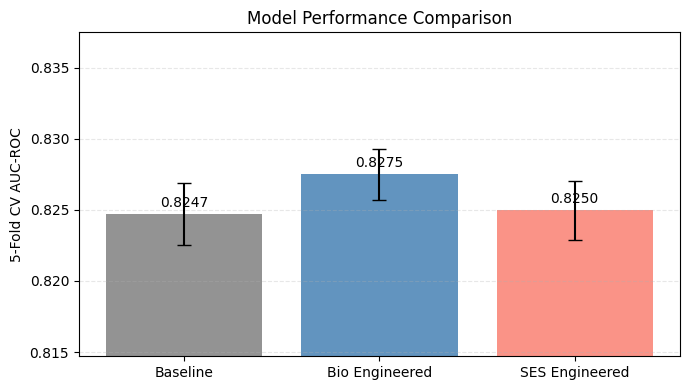

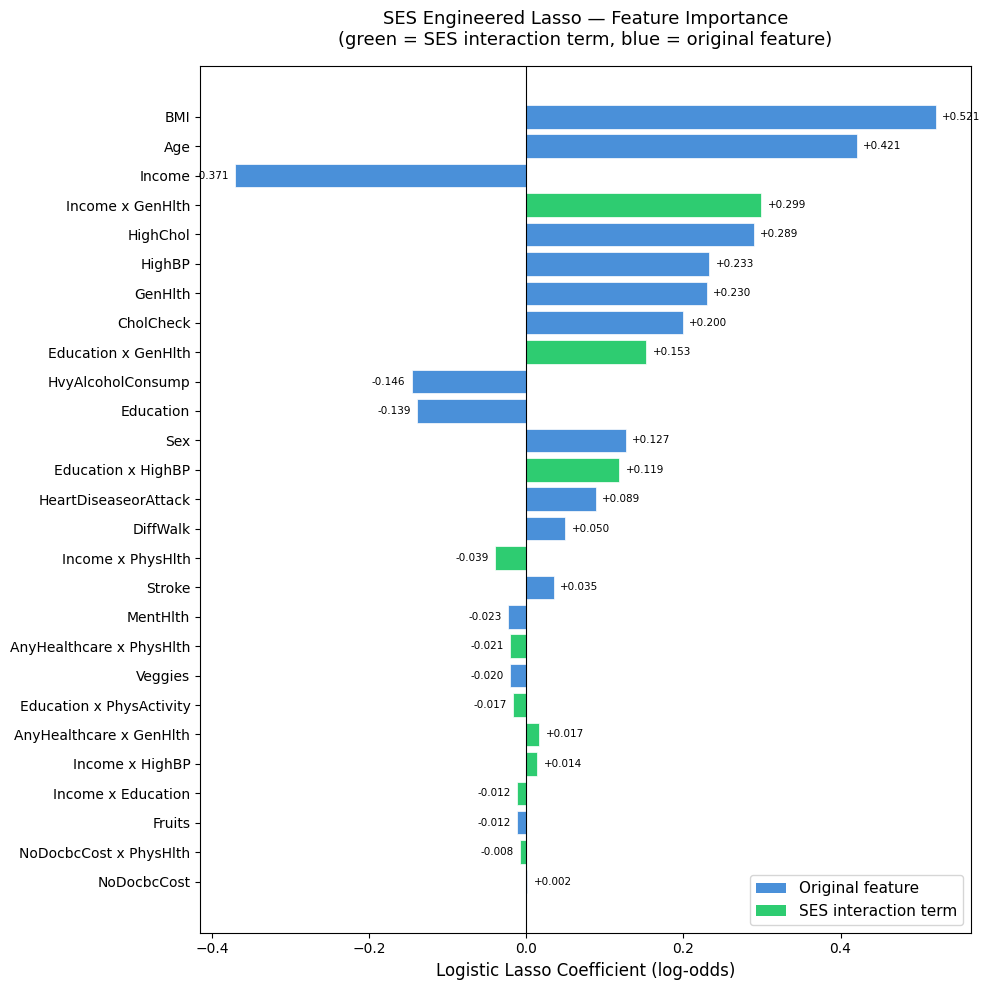

/tmp/ipykernel_384/3664725376.py:184: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby(["GenHlth", "IncomeQuartile"])["Diabetes"].mean().reset_index()


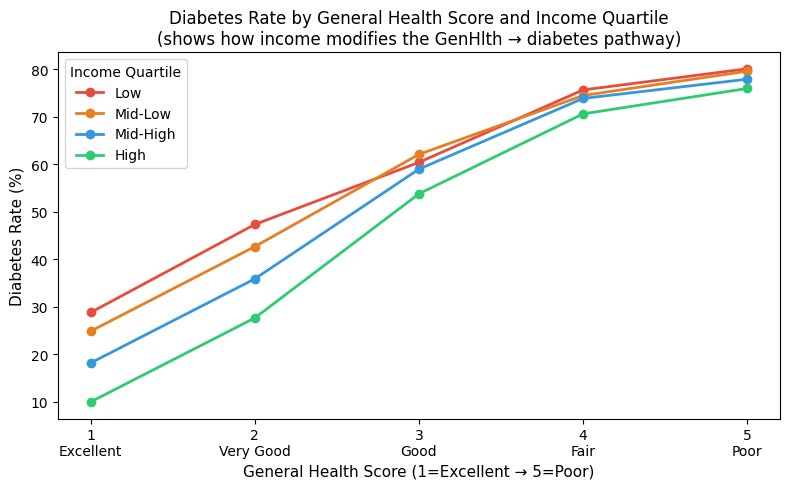

In [12]:
# Socioeconomic x Health Indicator Interactions

from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import roc_auc_score

ses_interaction_pairs = [
    # Income crossing with health indicators
    ("Income",       "GenHlth"),       # does low income amplify poor health risk?
    ("Income",       "PhysHlth"),      # economic stress -> physical health days lost
    ("Income",       "DiffWalk"),      # low income + physical limitation
    ("Income",       "BMI"),           # is high BMI riskier in lower income patients?
    ("Income",       "HighBP"),        # access to BP management
    ("Income",       "HeartDiseaseorAttack"),  # cardiac risk moderated by resources

    # Education crossing with health indicators
    ("Education",    "GenHlth"),       # does education moderate the health-diabetes pathway?
    ("Education",    "BMI"),           # health literacy around weight management
    ("Education",    "PhysActivity"),  # knowledge translating to behavior

    # Healthcare access crossing with health indicators
    ("AnyHealthcare","GenHlth"),       # does insurance moderate how health affects diabetes?
    ("AnyHealthcare","PhysHlth"),      # access buffering physical health days
    ("AnyHealthcare","HighBP"),        # BP management with insurance
    ("NoDocbcCost",  "GenHlth"),       # couldn't afford care AND poor health
    ("NoDocbcCost",  "PhysHlth"),      # cost barrier + physical health burden

    # SES composite crossing with top clinical predictors
    ("Education",    "HighBP"),        # health literacy around hypertension management

    # Pure SES interactions — composite socioeconomic status
    ("Income",       "Education"),     # combined SES: wealth + knowledge together
    ("Income",       "AnyHealthcare"), # wealth determines insurance coverage
    ("NoDocbcCost",  "AnyHealthcare"), # insured but still couldn't afford care — access gap
]

# deduplicate in case of overlap
seen = set()
ses_interaction_pairs_clean = []
for pair in ses_interaction_pairs:
    key = tuple(sorted(pair))
    if key not in seen:
        seen.add(key)
        ses_interaction_pairs_clean.append(pair)

ses_interaction_names = [f"{a} x {b}" for a, b in ses_interaction_pairs_clean]

# Build engineered matrix: original features + SES interactions
X_ses = X_raw.copy()
for a, b in ses_interaction_pairs_clean:
    col = f"{a} x {b}"
    X_ses[col] = X_raw[a] * X_raw[b]

ses_feature_names = list(X_ses.columns)
X_ses_scaled = StandardScaler().fit_transform(X_ses)

print(f"Original features:    {X_raw.shape[1]}")
print(f"SES interactions:     {len(ses_interaction_pairs_clean)}")
print(f"Total features:       {X_ses.shape[1]}")

# Fit SES Engineered Logistic LASSO
lasso_ses = LogisticRegressionCV(
    Cs=Cs, penalty="l1", solver="liblinear",
    cv=cv, max_iter=1000, random_state=42, scoring="roc_auc"
)
lasso_ses.fit(X_ses_scaled, y)
coef_ses = pd.Series(lasso_ses.coef_[0], index=ses_feature_names)

print(f"\n[SES Engineered] Best C = {lasso_ses.C_[0]:.5f} | Non-zero: {(coef_ses != 0).sum()} / {len(ses_feature_names)}")
print("\nAll selected features:")
print(coef_ses[coef_ses != 0].sort_values(key=abs, ascending=False).to_string())

# Which SES interactions were selected?
sel_ses = coef_ses[ses_interaction_names]
sel_ses = sel_ses[sel_ses != 0].sort_values(key=abs, ascending=False)

print("\n=== SES interaction terms selected by Lasso ===")
if len(sel_ses):
    print(sel_ses.to_string())
    print("\n--- Component status ---")
    for name in sel_ses.index:
        a, b = name.split(" x ", 1)
        ca = coef_ses.get(a, 0)
        cb = coef_ses.get(b, 0)
        print(f"  {name}: {sel_ses[name]:+.4f}")
        print(f"    {a}: {ca:+.4f}{'  (zeroed)' if ca == 0 else ''}")
        print(f"    {b}: {cb:+.4f}{'  (zeroed)' if cb == 0 else ''}")
else:
    print("  None selected.")


# VISUALIZATION 1 — full coefficient chart
nonzero_ses = coef_ses[coef_ses != 0].copy()
nonzero_ses = nonzero_ses.reindex(nonzero_ses.abs().sort_values(ascending=True).index)
is_ses_int  = nonzero_ses.index.isin(ses_interaction_names)
bar_colors  = ["#2ecc71" if inter else "#4a90d9" for inter in is_ses_int]

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(nonzero_ses.index, nonzero_ses.values, color=bar_colors,
               edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Logistic Lasso Coefficient (log-odds)", fontsize=12)
ax.set_title("SES Engineered Lasso — Feature Importance\n(green = SES interaction term, blue = original feature)",
             fontsize=13, pad=15)
legend_elements = [
    Patch(facecolor="#4a90d9", label="Original feature"),
    Patch(facecolor="#2ecc71", label="SES interaction term"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=11)
for bar, val in zip(bars, nonzero_ses.values):
    x_pos = val + 0.008 if val >= 0 else val - 0.008
    ha = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=7.5)
plt.tight_layout()
plt.show()

# VISUALIZATION 3 - direct comparison of GenHlth across income levels
# Shows the raw data: average diabetes rate by GenHlth score, split by income quartile
df_plot = X_raw.copy()
df_plot["Diabetes"] = y
df_plot["IncomeQuartile"] = pd.cut(df_plot["Income"], bins=[0, 2, 4, 6, 8],
                                    labels=["Low", "Mid-Low", "Mid-High", "High"])

grouped = df_plot.groupby(["GenHlth", "IncomeQuartile"])["Diabetes"].mean().reset_index()
pivot   = grouped.pivot(index="GenHlth", columns="IncomeQuartile", values="Diabetes")

fig, ax = plt.subplots(figsize=(8, 5))
colors_q = ["#e74c3c", "#e67e22", "#3498db", "#2ecc71"]
for col, color in zip(pivot.columns, colors_q):
    ax.plot(pivot.index, pivot[col] * 100, marker="o", label=col, color=color, lw=2)

ax.set_xlabel("General Health Score (1=Excellent → 5=Poor)", fontsize=11)
ax.set_ylabel("Diabetes Rate (%)", fontsize=11)
ax.set_title("Diabetes Rate by General Health Score and Income Quartile\n"
             "(shows how income modifies the GenHlth → diabetes pathway)", fontsize=12)
ax.legend(title="Income Quartile", fontsize=10)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(["1\nExcellent", "2\nVery Good", "3\nGood", "4\nFair", "5\nPoor"])
plt.tight_layout()
plt.show()


Then we wanted to see what the predictive performance of just the SES Engineered LASSO model.


=== 5-fold CV AUC-ROC ===
Baseline        0.8247 +/- 0.0022
Physio-Engineered 0.8275 +/- 0.0018
SES-Engineered  0.8250 +/- 0.0021


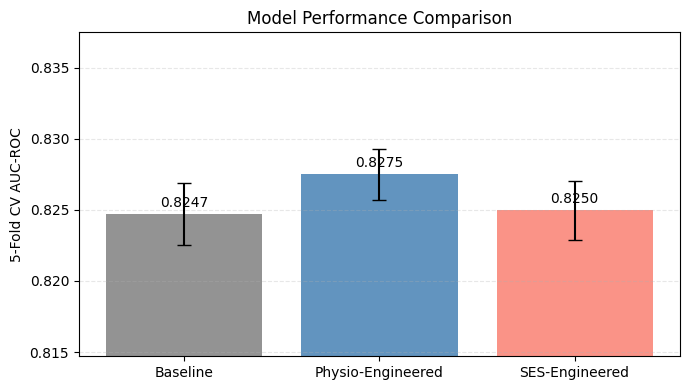

In [13]:
# AUC COMPARISON
def cv_auc(model, X, y, cv):
    aucs = []
    for train_idx, test_idx in cv.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        prob = model.predict_proba(X[test_idx])[:, 1]
        aucs.append(roc_auc_score(y[test_idx], prob))
    return np.mean(aucs), np.std(aucs)

auc_ses = cv_auc(
    LogisticRegression(C=lasso_ses.C_[0], penalty="l1", solver="liblinear", max_iter=1000),
    X_ses_scaled, y, cv
)

# Store all model results
results = {
    "Baseline": (0.8247, 0.0022),
    "Physio-Engineered": (0.8275, 0.0018),
    "SES-Engineered": auc_ses
}

print("\n=== 5-fold CV AUC-ROC ===")
for name, (mean, std) in results.items():
    print(f"{name:<15} {mean:.4f} +/- {std:.4f}")

# Plot
means = [v[0] for v in results.values()]
stds  = [v[1] for v in results.values()]
labels = list(results.keys())

plt.figure(figsize=(7, 4))

bars = plt.bar(
    labels,
    means,
    yerr=stds,
    capsize=5,
    color=["gray", "steelblue", "salmon"],
    alpha=0.85
)

# Annotate bars
for bar, mean in zip(bars, means):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        mean + 0.0005,
        f"{mean:.4f}",
        ha="center",
        fontsize=10
    )

plt.ylabel("5-Fold CV AUC-ROC")
plt.title("Model Performance Comparison")
plt.ylim(min(means) - 0.01, max(means) + 0.01)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Tests

In [ ]:

!wget https://raw.githubusercontent.com/IsaacBFine/diabetes-predictors/refs/heads/main/Tests/test_feature_engineering.py

!python -m pytest test_feature_engineering.py -v


--2026-06-10 18:55:42--  https://raw.githubusercontent.com/IsaacBFine/diabetes-predictors/refs/heads/main/Tests/test_feature_engineering.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16676 (16K) [text/plain]
Saving to: ‘test_feature_engineering.py.2’

test_feature_engine 100%[===================>]  16.29K  --.-KB/s    in 0.003s  

2026-06-10 18:55:42 (5.63 MB/s) - ‘test_feature_engineering.py.2’ saved [16676/16676]

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: typeguard-4.5.2, anyio-4.13.0, langsmith-0.8.9
collected 33 items                                                             

te